In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Arc
from matplotlib.lines import Line2D
from ICONProcessor import ICONDataGrid

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [2]:
def add_dt_text(ax, dt, bg_fill=False):
    if bg_fill: bbox = dict(facecolor="white", edgecolor="none",alpha=0.8, boxstyle="square,pad=0.4")
    else: bbox=None
    ax.text(0.01, 0.01, dt.strftime("%H:%M UTC"),
        transform=ax.transAxes,
        fontsize=10, ha="left", va="bottom", color="black", zorder=15,
        bbox=bbox)

def add_direction(ax, angle):
    if angle == 25:
        tl,tr = 'SSW','NNE'
    elif angle == 115:
        tl,tr = 'WNW','ESE'
    else:
        return
    ax.text(0.01, 0.98, tl, transform=ax.transAxes,fontsize=10, ha="left", va="top", color="black", zorder=15)
    ax.text(0.99, 0.98, tr, transform=ax.transAxes,fontsize=10, ha="right", va="top", color="black", zorder=15)

def add_dem(ax, dem_vals, zmin):
    dem_x = np.linspace(-scan_length, scan_length + 1, len(dem_vals))
    ax.fill_between(dem_x, y1=zmin, y2=dem_vals, color="lightgrey", zorder=9)
    ax.plot(dem_x, dem_vals, c='k')

def add_range_semicircles_and_gridlines(ax, radii, center=(0, 0), **kwargs):
    # circular lines
    for r in radii:
        arc = Arc(center, width=2 * r, height=2 * r, angle=0, theta1=0, theta2=360,**kwargs)
        ax.add_patch(arc)

    # radial lines
    r_max = max(radii)
    cx, cz = center
    angles_deg = [0, -45, 45]
    for angle in angles_deg:
        theta = np.deg2rad(angle)
        x_end = cx + (r_max + 1000) * np.sin(theta)
        z_end = cz + (r_max + 1000) * np.cos(theta)

        line = Line2D([cx, x_end], [cz, z_end],**kwargs)
        ax.add_line(line)

## Script settings

In [3]:
# date and hours of day to be visualized
dt_from = "2025-08-10"

# Lidar settings
range_gates = 18
rhi_angles = [25, 115]
scan_length=2000
zmax=1100

## Load data

In [4]:
dt_from = pd.to_datetime(dt_from)
dt_to = dt_from + pd.Timedelta(hours=24)

data_icon = {}
data_rhi = {}

for angle in rhi_angles:
    data_icon[angle] = xr.open_dataset(data_dir + f'HEFEX3__ICON_v370_2030_lidar_location_{angle}deg__avg30min_20250806-20250831.nc').sel(time=slice(dt_from, dt_to))
    data_rhi[angle] = xr.open_dataset(data_dir + f'HEFEX3__Obs_RHI_{angle}deg_RGL{range_gates}m_L2__avg30min_20250806-20250817.nc').sel(half_hour=slice(dt_from, dt_to))

In [5]:
# get outline of Hintereisferner (HEF)
rgi = gpd.read_file('/Users/geoalxx/Python/icon_validation/data_in/Glacier_Outlines_v370_2030_smoothed.geojson')
rgi_hef = rgi.loc[rgi['rgi_id'] == 'RGI60-11.00897']

In [14]:
# get ICON 2D wind field
ds_wind = xr.open_dataset('/Users/geoalxx/Python/glacier_space/data_icon_h3/levante_v370_2030/v370_2030_LES_30min_51m_ml_latlon_100x100_20250810.nc')
ds_wind = ds_wind.isel(lat=slice(25, 75), lon=slice(25, 75))

dt_ml = [ICONDataGrid.convert_float_dt(f) for f in ds_wind.time.values]
lat_ml, lon_ml = ds_wind.lat.values, ds_wind.lon.values
z_sfc = ds_wind.z_mc.values[-1,:,:] - 5

In [7]:
# get scan line geometries
gdf_scan_line = gpd.read_file('../data_in/H3_lidar_RHI_data.gpkg', layer='scan_lines_2000m')
gdf_scan_line = gdf_scan_line.to_crs('EPSG:4326')

,angle_deg,geometry
0,25,"LINESTRING (10.76007 46.7855, 10.77168 46.8016..."
1,80,"LINESTRING (10.74578 46.7989, 10.77168 46.8016..."
2,115,"LINESTRING (10.74818 46.8096, 10.77168 46.8016..."


## Prepare DEMs

In [8]:
dem_icon = {}
dem_rhi = {}
zmin = {}

for angle in rhi_angles:
    #--- ICON: DEM is determined by invalid data points
    ds_icon = data_icon[angle]
    x_icon = ds_icon.horizontal_dist.values
    z_icon = ds_icon.height.values

    mask = ~np.isnan(ds_icon.isel(time=0).rv)
    dem_icon[angle] = z_icon[mask.argmax(axis=0)]

    #--- RHI: get DEM for RHI scan from previously created GeoPackage (see notebooks/compute_rhi_geometries.ipynb)
    gdf = gpd.read_file('../data_in/H3_lidar_RHI_data.gpkg', layer=f'scan_line_{scan_length}m_{angle}deg_elev')
    dem_elev = gdf['elevation'].values

    # since plot shows height agl, we need to lower the elevation profile that midpoint (=lidar location) is at 0 m agl
    n = len(dem_elev)
    offset = (dem_elev[n//2 - 1] + dem_elev[n//2]) / 2 if n % 2 == 0 else dem_elev[n//2]
    dem_rhi[angle] = dem_elev - offset

    #--- lowest z value based on used DEMs
    zmin[angle] = min(dem_icon[angle].min(), dem_rhi[angle].min())

## Create plot

In [9]:
def centers_to_edges(arr):
    edges = np.zeros((arr.shape[0] + 1, arr.shape[1] + 1))

    # interior
    edges[1:-1, 1:-1] = (
        arr[:-1, :-1]
        + arr[1:, :-1]
        + arr[:-1, 1:]
        + arr[1:, 1:]
    ) / 4

    # extrapolate boundaries
    edges[0, :] = 2*edges[1, :] - edges[2, :]
    edges[-1, :] = 2*edges[-2, :] - edges[-3, :]
    edges[:, 0] = 2*edges[:, 1] - edges[:, 2]
    edges[:, -1] = 2*edges[:, -2] - edges[:, -3]

    return edges

def plot_rhi_tile(ax, angle, t):
    ds_rhi = data_rhi[angle]

    #--- 1. Prep work
    # get timestamps
    dt_rhi = pd.to_datetime(ds_rhi.half_hour.isel(half_hour=t).values)

    # get actual data (radial velocity)
    dv_rhi  = ds_rhi.dv.isel(half_hour=t).values # open the RHI dataset at the respective index
    dv_rhi = np.flip(dv_rhi.T, axis=0)
    dv_rhi[:,:5] = np.nan # delete nearest 5 range gates (too much noise)

    # Get the cartesian coordinates for both plots
    x_rhi = ds_rhi.x.values
    z_rhi = ds_rhi.z.values

    # convert points to edges to avoid pcolormesh warnings
    x_edges = centers_to_edges(x_rhi)
    z_edges = centers_to_edges(z_rhi)

    #--- 2. RHI plot
    pcm = ax.pcolormesh(z_edges, x_edges, dv_rhi, shading="flat", cmap=cmap_rv, norm=norm_rv)
    add_dt_text(ax, dt_rhi)
    add_direction(ax, angle)
    add_dem(ax, dem_rhi[angle], min(zmin.values()))
    return pcm

def plot_icon_tile(ax, angle, t):
    ds_icon = data_icon[angle]

    #--- 1. Prep work
    # get timestamps
    dt_icon = pd.to_datetime(ds_icon.time.isel(time=t).values)

    # get actual data (radial velocity)
    dv_icon = ds_icon.rv.isel(time=t).values

    # prepare extent
    z_icon = ds_icon.height.values
    icon_extent = [-scan_length, scan_length, z_icon.min(), z_icon.max()]

    #--- 2. ICON plot
    im = ax.imshow(dv_icon, origin="lower", aspect="auto", interpolation="none", cmap=cmap_rv, norm=norm_rv, extent=icon_extent)
    add_dt_text(ax, dt_icon)
    add_direction(ax, angle)
    add_dem(ax, dem_icon[angle], min(zmin.values()))
    return im

def plot_windstream_tile(ax, angle, t, h=-1):
    #--- 1. Prep work
    # get wind field
    u_ml = ds_wind.u.values[t, h, :, :]
    v_ml = ds_wind.v.values[t, h, :, :]
    spd = np.sqrt(u_ml ** 2 + v_ml ** 2)

    # scan line for angle
    df_scan_line = gdf_scan_line[gdf_scan_line['angle_deg'] == angle].get_coordinates()

    #--- 2. Plot background (terrain, lidar location and scan line)
    ax.pcolormesh(lon_ml, lat_ml, z_sfc, cmap="terrain", shading="auto", alpha=.3)
    ax.plot(df_scan_line['x'],df_scan_line['y'], color='red',lw=1)
    ax.scatter(10.7717,46.801632, color='red', s=25, zorder=10, marker='D')

    #--- 3. Plot windstream
    sp = ax.streamplot(lon_ml, lat_ml, u_ml, v_ml, density=2.5, linewidth=1.5*spd/spd.max(), color=spd, cmap=cmap_ws, norm=norm_ws)
    add_dt_text(ax, dt_ml[t], bg_fill=True)

    rgi_hef.boundary.plot(ax=ax, color='k', lw=.5)
    ax.set_xlim(10.73,10.805)
    ax.set_ylim(46.79,46.8175)

    ax.set_xticks([])
    ax.set_yticks([])

    return sp

In [10]:
# discrete colormaps
vmin, vmax = -5.0, 5.0 # boundary values for the rv colormap
rv_step = 1

bounds_rv = np.arange(vmin, vmax+rv_step, rv_step)
cmap_rv = plt.get_cmap(cm.vik)
norm_rv = BoundaryNorm(bounds_rv, ncolors=cmap_rv.N, clip=True)

bounds_ws = np.arange(0, 8, 1)
cmap_ws = plt.get_cmap(cm.lajolla)
norm_ws = BoundaryNorm(bounds_ws, ncolors=cmap_ws.N, clip=True)

In [11]:
# # discrete colormap
# vmin, vmax = -5.0, 5.0 # boundary values for the rv colormap
# rv_step = 1
#
# bounds = np.arange(vmin, vmax+rv_step, rv_step)
# cmap = plt.get_cmap(cm.vik)
# norm = BoundaryNorm(bounds, ncolors=cmap.N, clip=True)
#
#
# fig, axes = plt.subplots(5, 4, figsize=(12,10), sharex=True, sharey=True)
#
# row,col=0,0
#
# angle = 25
# full_hours = np.array([5,8,10,12,14,16,18,20,22,24])
# half_hours = (full_hours * 2).astype(int)
# for i, t in tqdm(enumerate(half_hours)):
#     if i % 5 == 0 and i != 0:
#         row = 0
#         col += 2
#     else:
#         row = i % 5
#
#     pcm = plot_rhi_tile(axes[row, col], angle, t)
#     plot_icon_tile(axes[row, col+1], angle, t)
#
# # limits and grid
# for i,ax in enumerate(axes.flat):
#     ax.set_xlim(-1200, 1200)
#     ax.set_ylim(zmin[angle],zmax)
#     ax.set_aspect("equal")
#     add_range_semicircles_and_gridlines(ax, radii=[200, 500, 1000], zorder=8,
#                                         lw=.5, ls='--', color='black', alpha = 0.5)
#     for s in ax.spines.values(): s.set_zorder(50)   # subplot frame on top of DEM overlay
#     if i % 4 == 0: ax.set_ylabel('Height (m AGL)')  # y labels for left column
#     if i >= 16: ax.set_xlabel('Distance (m)')
#
# # colorbar
# cax = fig.add_axes([0.313, 0.12, 0.4, 0.02])
# fig.colorbar(pcm, cax=cax, orientation="horizontal",
#              boundaries=bounds, ticks=bounds, extend='both',
#              label=r"Radial velocity (m s$^{-1}$)")
#
# # add vertical separator between 2nd and 3rd column
# sep = Line2D([0.513, 0.513], [0.165, .945], transform=fig.transFigure, color='k', linewidth=2)
# fig.add_artist(sep)
#
# # final formatting
# fig.subplots_adjust(left=0.05, right=0.98, top=1,
#                     bottom=0.15, wspace=0.075, hspace=-0.4)
# #plt.savefig(fig_png_dir + f'HEF_RHI_ICON_{rhi_angle}deg_{dt_from.strftime('%Y%m%d')}.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
# #plt.savefig(fig_pdf_dir + f'HEF_RHI_ICON_{rhi_angle}deg_{dt_from.strftime('%Y%m%d')}.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
# plt.show()

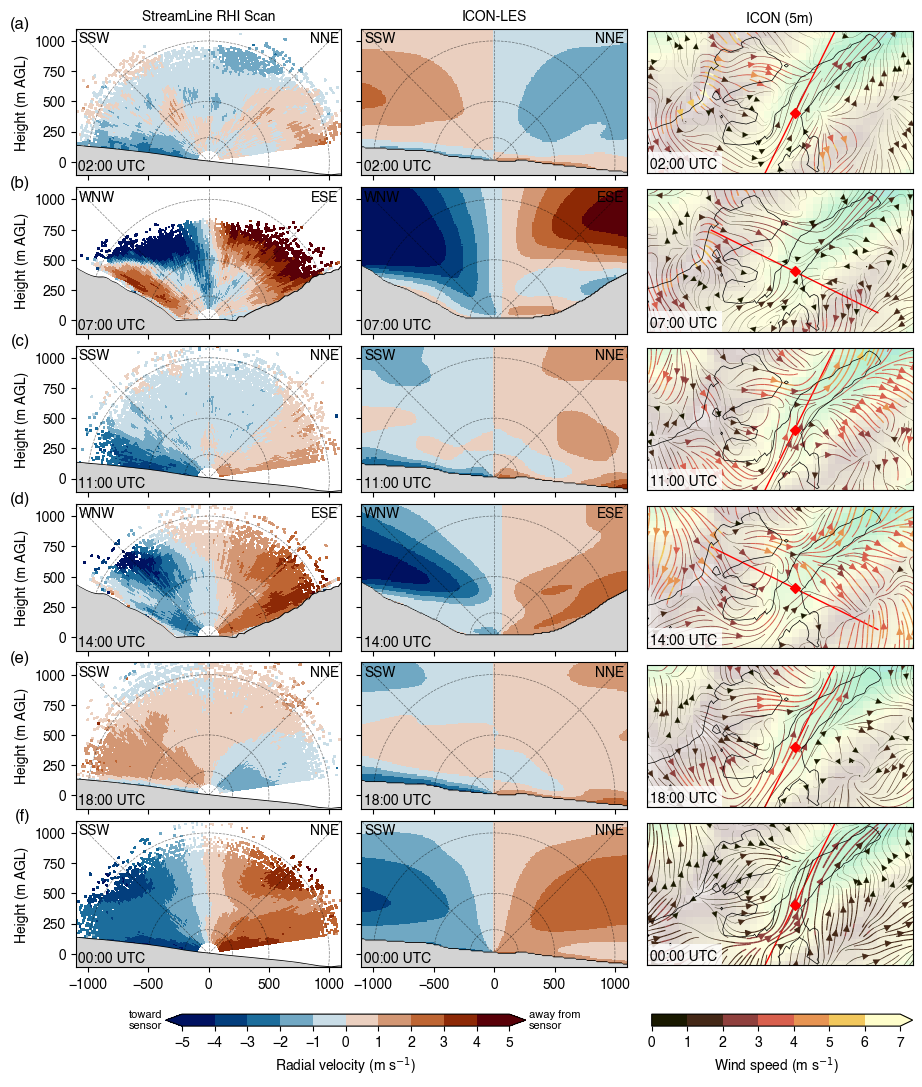

In [18]:
fig, axs = plt.subplots(nrows=6, ncols=3, figsize=(9,12), sharex='col')

# define full hour and angle (h,a) settings for plotting
plt_config = [(2,25), (7,115), (11,25), (14,115), (18,25), (24,25)]

# plot tiles for each row
for i,c in enumerate(plt_config):
    t = int(c[0] * 2) # convert hour to half-hour index
    angle = c[1]

    pcm = plot_rhi_tile(axs[i, 0], angle, t)
    plot_icon_tile(axs[i, 1], angle, t)
    sp = plot_windstream_tile(axs[i, 2], angle, t)


# limits and grid (first two columns)
for i,ax in enumerate(axs.flat):
    for s in ax.spines.values(): s.set_zorder(50)
    if i % 3 < 2:
        ax.set_xlim(-1100, 1100)
        ax.set_ylim(min(zmin.values()),1100)
        ax.set_aspect("equal")
        add_range_semicircles_and_gridlines(ax, radii=[200, 500, 1000], zorder=8,
                                            lw=.5, ls='--', color='black', alpha = 0.5)

    if i % 3 == 1:
        ax.tick_params(labelleft=False)

# column titles
axs[0][0].set_title('StreamLine RHI Scan', fontsize=10)
axs[0][1].set_title('ICON-LES', fontsize=10)
axs[0][2].set_title('ICON (5m)', fontsize=10)

# panel letters
import string
for ax, letter in zip(axs[:,0], string.ascii_lowercase):
    ax.set_ylabel('Height (m AGL)')
    x=-0.17
    ax.text(
        x, .98, f'({letter})',
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        va='bottom', ha='right'
    )

# colorbar for RHI scans
cax = fig.add_axes([0.15, 0.12, 0.4, 0.01])
cbar = fig.colorbar(pcm, cax=cax, orientation="horizontal",extend='both',
             boundaries=bounds_rv, ticks=bounds_rv,
             label=r"Radial velocity (m s$^{-1}$)")
cbar.ax.text(-0.06, .5, "toward\nsensor", transform=cbar.ax.transAxes, ha='right', va='center', fontsize=8)
cbar.ax.text(1.06, 0.5, "away from\nsensor", transform=cbar.ax.transAxes, ha='left', va='center', fontsize=8)

# colorbar for streamplot
cax = fig.add_axes([0.69, 0.12, 0.29, 0.01])
fig.colorbar(sp.lines, cax=cax, orientation="horizontal",extend='max',
             label=r"Wind speed (m s$^{-1}$)")

# final formatting
fig.subplots_adjust(left=0.05, right=0.98, top=1, bottom=0.12, wspace=0.075, hspace=-0.4)

# save figures
plt.savefig(fig_png_dir + f'HEF_RHI_ICON_{dt_from.strftime('%Y%m%d')}.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_RHI_ICON_{dt_from.strftime('%Y%m%d')}.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)